# Usage of VIT model

This notebook was just for test purposes, to see if loading and running the VIT model on the Mappillary traffic sign dataset works

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


In [14]:
import torch.nn as nn
import torchvision.models as models
import timm

class ViTModel(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(ViTModel, self).__init__()

        # Create ViT base model
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=pretrained)

        # Replace classification head
        self.vit.head = nn.Linear(self.vit.head.in_features, num_classes)

    def forward(self, x):
        return self.vit(x)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load('ViTModel/best.pth', map_location=torch.device('cpu'))
model = ViTModel(num_classes=len(checkpoint["label_map"]), pretrained=False)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

ViTModel(
  (vit): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): G

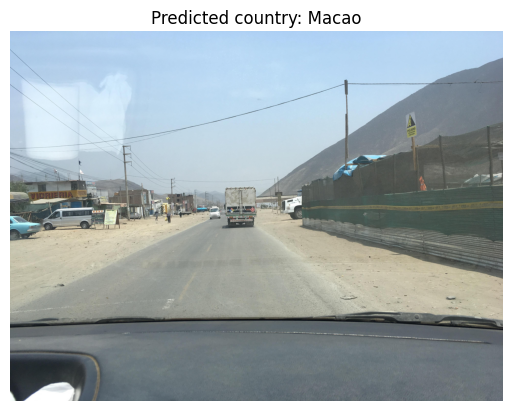

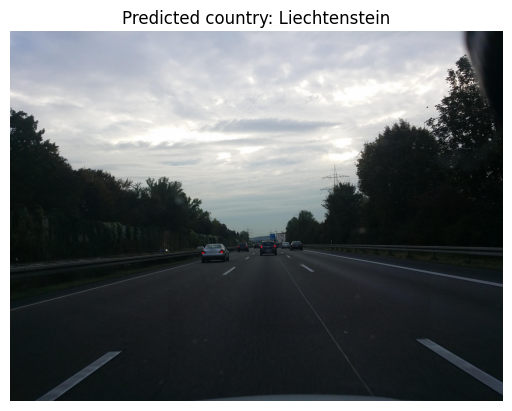

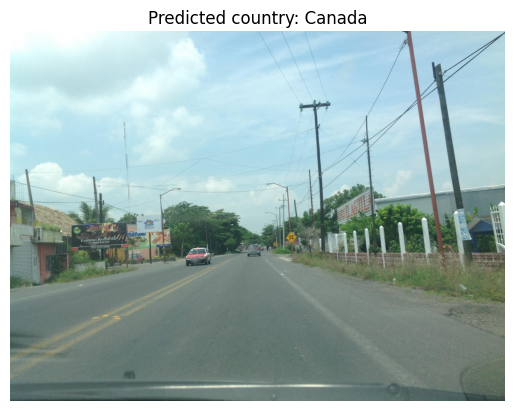

In [12]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

# --- Config ---
VAL_DIR = "dataset/images/val"  # path to your validation folder
NUM_IMAGES = 3   # number of images to test
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

idx_to_name = {v: k for k, v in checkpoint["label_map"].items()}


# --- Transformations matching ViT input ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ViT base patch16_224 expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))  # standard for ViT in timm
])

# --- Get 3 sample images ---
image_files = [f for f in os.listdir(VAL_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:NUM_IMAGES]

for img_file in image_files:
    # Load and transform image
    img_path = os.path.join(VAL_DIR, img_file)
    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)  # add batch dimension

    # Run inference
    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_idx = outputs.argmax(dim=1).item()
        #predicted_label = checkpoint["label_map"][predicted_idx]
        predicted_label = idx_to_name[predicted_idx]

    # Display image with prediction
    plt.imshow(image)
    plt.title(f"Predicted country: {predicted_label}")
    plt.axis("off")
    plt.show()